In [516]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.api import stats as sm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.feature_selection import RFE

import warnings
warnings.filterwarnings('ignore')

In [517]:
df_bike = pd.read_csv("../../ml_data/bike.csv")

In [518]:
df_bike.shape

(730, 16)

#### Data Processing

In [519]:
# check for missing values
df_bike.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [520]:
df_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [521]:
df_bike.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [522]:
df_bike.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,730.0,365.500000,210.877136,1.000000,183.250000,365.500000,547.750000,730.000000
season,730.0,2.498630,1.110184,1.000000,2.000000,3.000000,3.000000,4.000000
yr,730.0,0.500000,0.500343,0.000000,0.000000,0.500000,1.000000,1.000000
mnth,730.0,6.526027,3.450215,1.000000,4.000000,7.000000,10.000000,12.000000
holiday,730.0,0.028767,0.167266,0.000000,0.000000,0.000000,0.000000,1.000000
weekday,730.0,2.995890,2.000339,0.000000,1.000000,3.000000,5.000000,6.000000
workingday,730.0,0.690411,0.462641,0.000000,0.000000,1.000000,1.000000,1.000000
weathersit,730.0,1.394521,0.544807,1.000000,1.000000,1.000000,2.000000,3.000000
temp,730.0,20.319259,7.506729,2.424346,13.811885,20.465826,26.880615,35.328347
atemp,730.0,23.726322,8.150308,3.953480,16.889713,24.368225,30.445775,42.044800


You can observe in the dataset that some of the variables like 'weathersit' and 'season' have values as 1, 2, 3, 4 which have specific labels associated with them (as can be seen in the data dictionary). These numeric values associated with the labels may indicate that there is some order to them - which is actually not the case (Check the data dictionary and think why). So, it is advisable to convert such feature values into categorical string values before proceeding with model building. Please refer the data dictionary to get a better understanding of all the independent variables


In [523]:
df_bike['month']=df_bike.mnth.map({1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'June',7:'July',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'})

In [524]:
df_bike['weekday']=df_bike.weekday.map({0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'})

In [525]:
df_bike['season']=df_bike.season.map({1: 'spring', 2: 'summer',3:'fall', 4:'winter' })

In [526]:
df_bike.nunique().sort_values()

workingday      2
yr              2
holiday         2
weathersit      3
season          4
weekday         7
month          12
mnth           12
temp          498
hum           594
casual        605
windspeed     649
registered    678
atemp         689
cnt           695
dteday        730
instant       730
dtype: int64

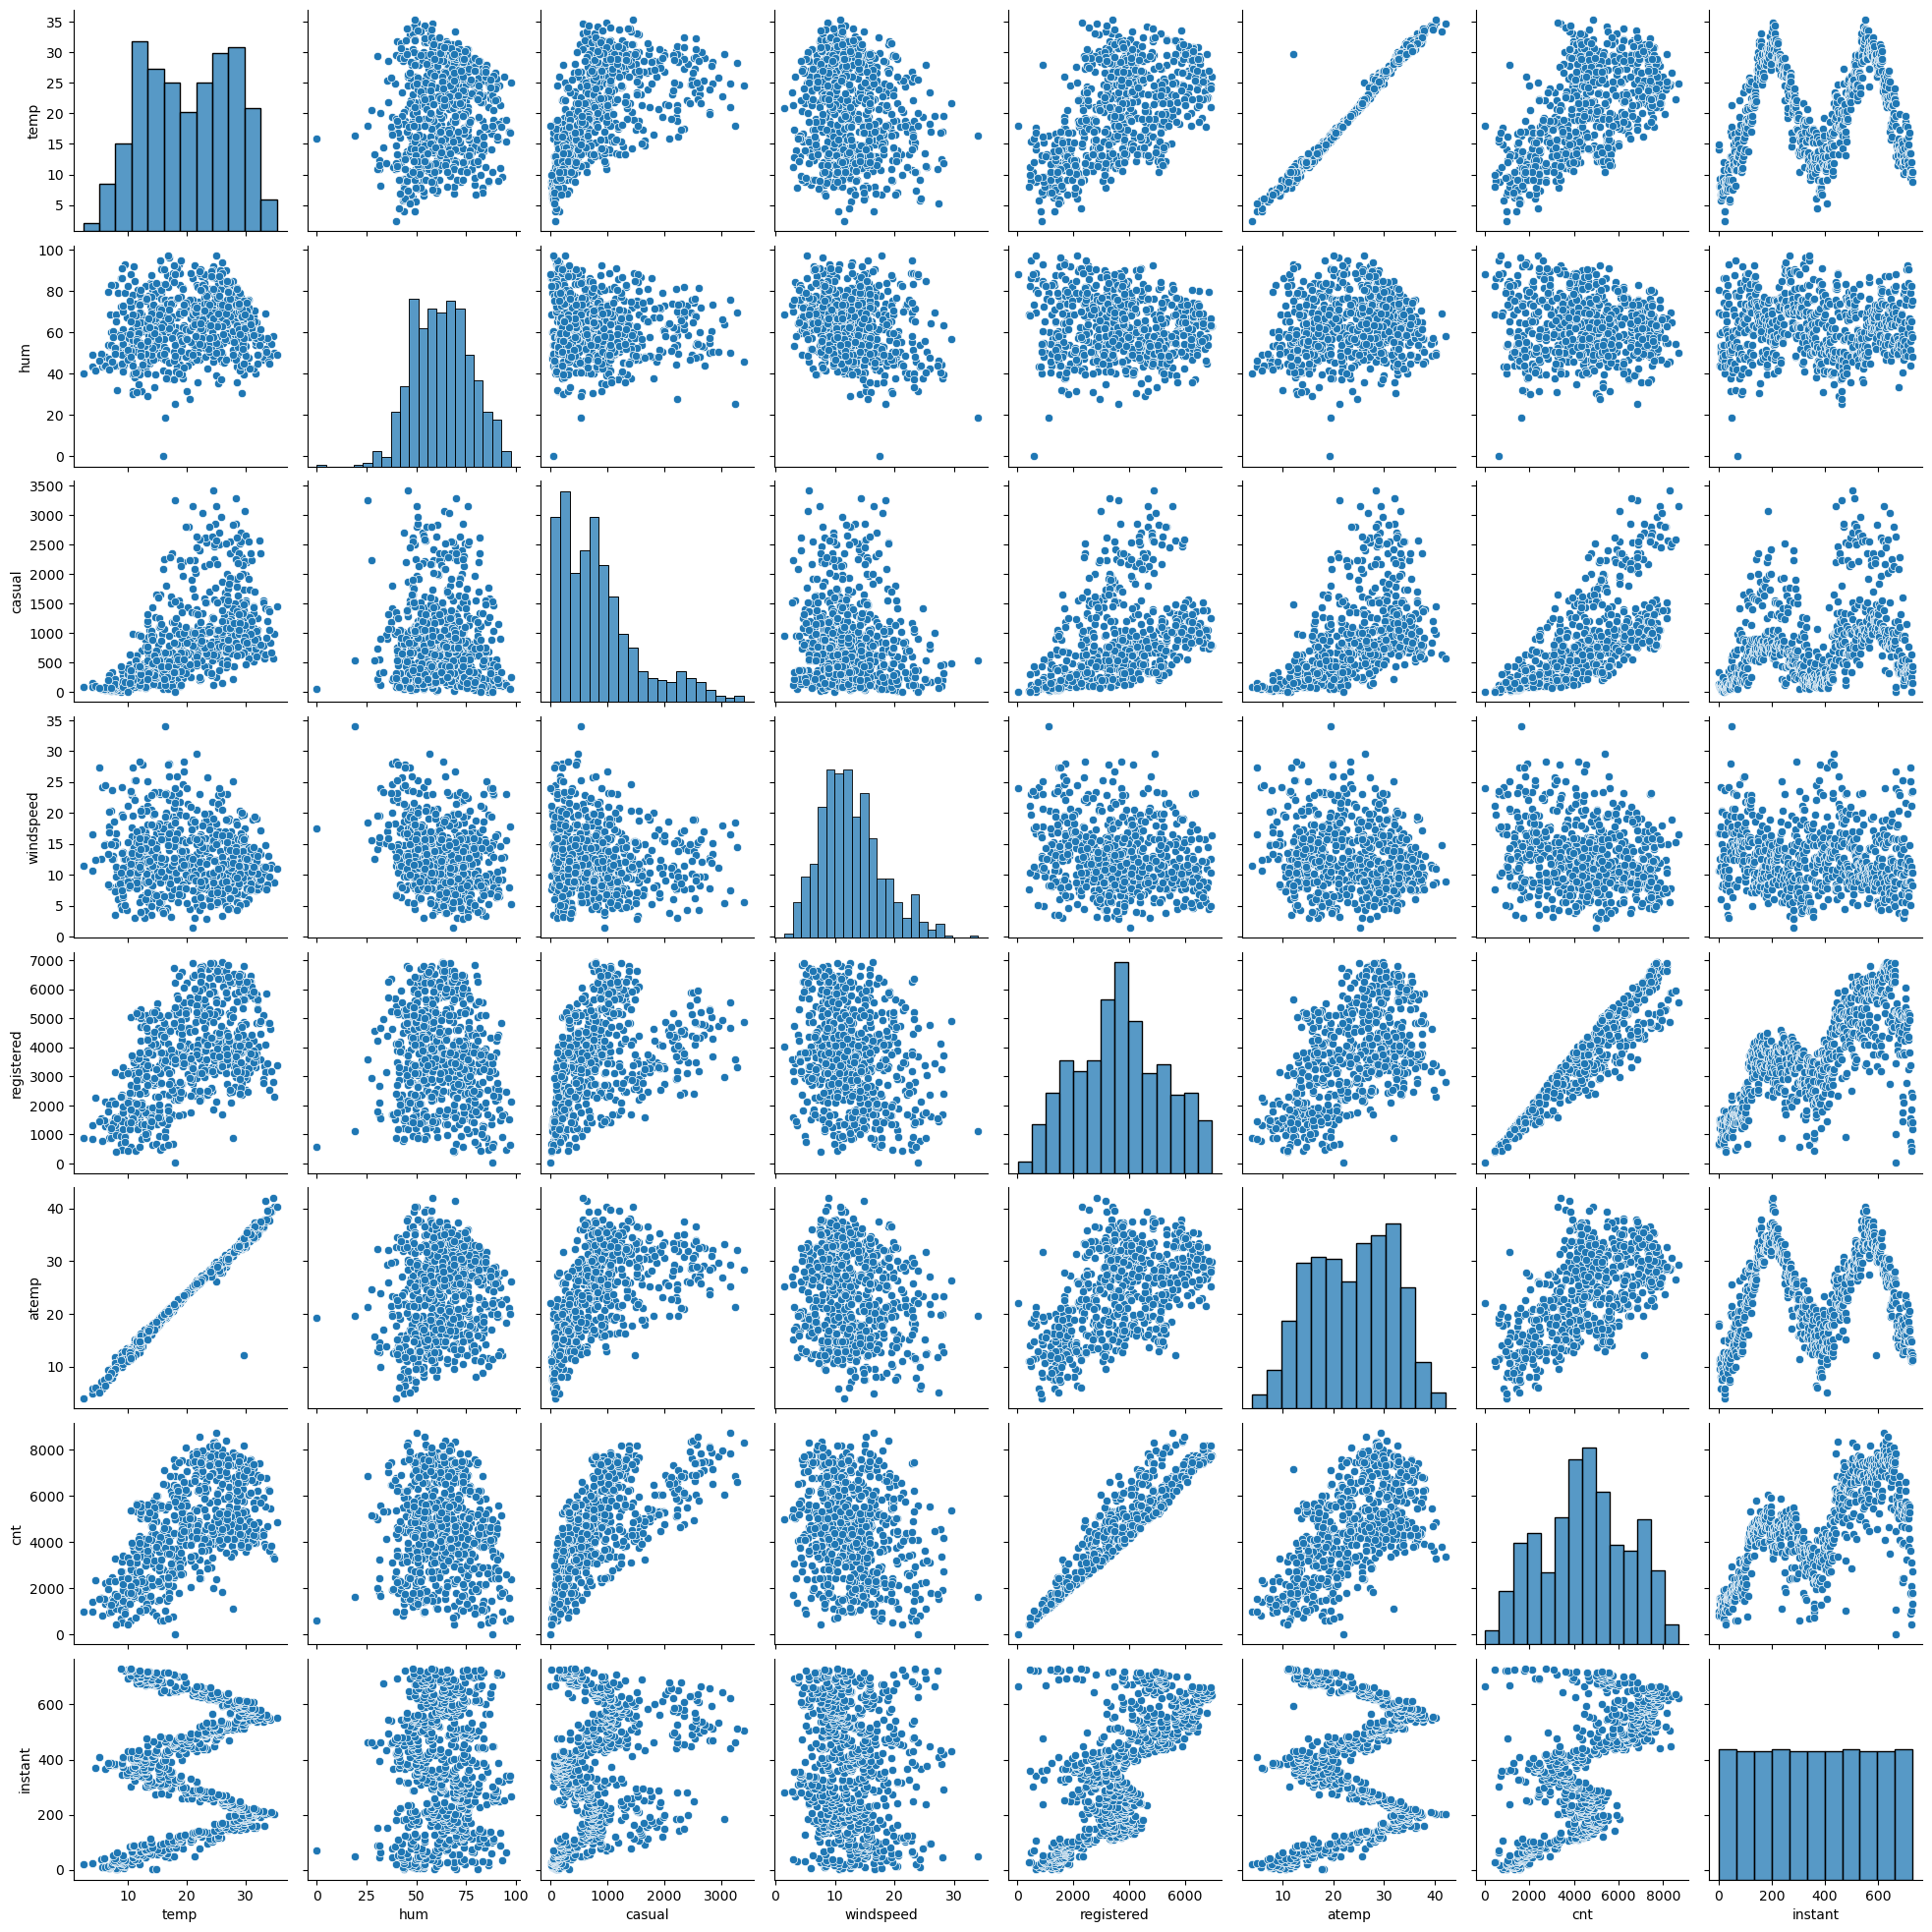

In [527]:
sns.pairplot(data=df_bike, vars=["temp", "hum",'casual','windspeed','registered','atemp','cnt','instant']);

In [528]:
df_bike.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,month
0,1,01-01-2018,spring,0,1,0,Mon,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985,Jan
1,2,02-01-2018,spring,0,1,0,Tue,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801,Jan
2,3,03-01-2018,spring,0,1,0,Wed,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349,Jan
3,4,04-01-2018,spring,0,1,0,Thu,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562,Jan
4,5,05-01-2018,spring,0,1,0,Fri,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600,Jan


#### Univariate analysis

In [529]:
df_bike['weathersit'].value_counts()

weathersit
1    463
2    246
3     21
Name: count, dtype: int64

In [530]:
df_bike['yr'].value_counts()

yr
0    365
1    365
Name: count, dtype: int64

In [531]:
df_bike['season'].value_counts()

season
fall      188
summer    184
spring    180
winter    178
Name: count, dtype: int64

In [532]:
df_bike['workingday'].value_counts()

workingday
1    504
0    226
Name: count, dtype: int64

In [533]:
df_bike['weathersit'].value_counts()

weathersit
1    463
2    246
3     21
Name: count, dtype: int64

<Axes: xlabel='cnt', ylabel='Count'>

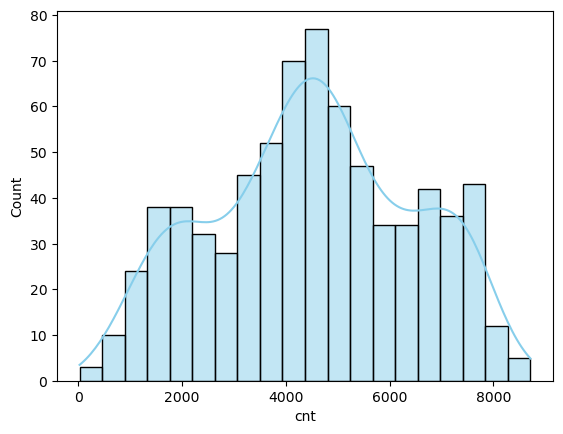

In [534]:
sns.histplot(df_bike['cnt'], bins=20, kde=True, color='skyblue')

<Axes: xlabel='atemp', ylabel='Count'>

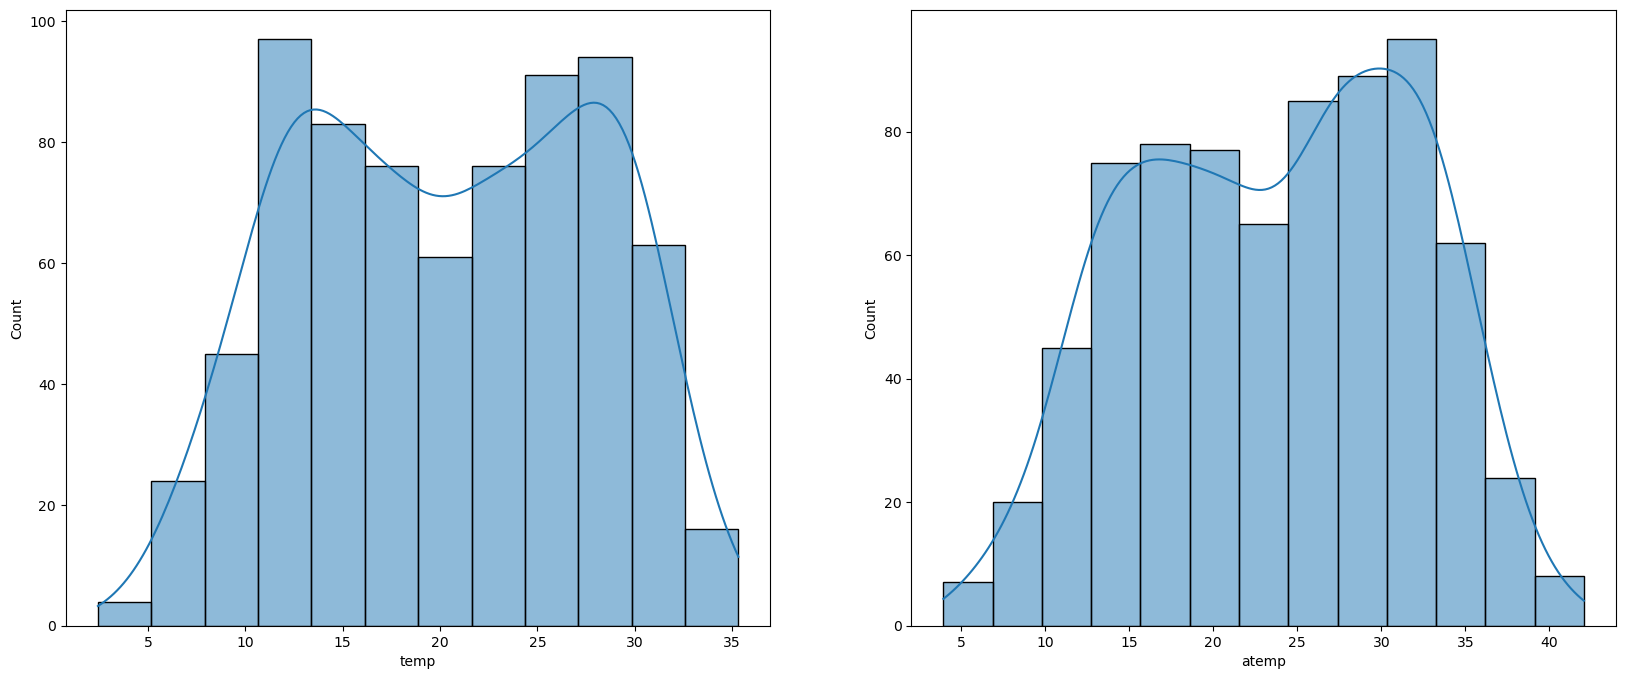

In [535]:
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(121)
sns.histplot(df_bike['temp'], kde=True)

ax = fig.add_subplot(122)
sns.histplot(df_bike['atemp'], kde=True)

<Axes: xlabel='holiday', ylabel='count'>

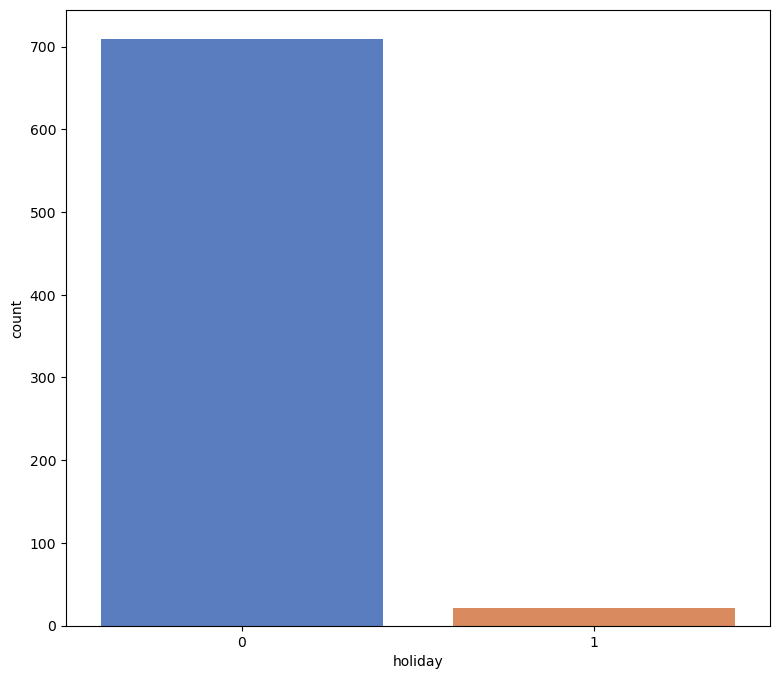

In [536]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(121)
sns.countplot(data=df_bike, x="holiday",palette="muted") # Plot holiday data

#### Bivariate analysis

In [537]:
wather_code = {1: 'Clear', 2: 'Cloudy', 3: 'Little Bad', 4: 'Worse'}

# Map the numerical values to their corresponding labels
df_bike['weathersit'] = df_bike['weathersit'].map(wather_code)

<Axes: xlabel='weekday', ylabel='cnt'>

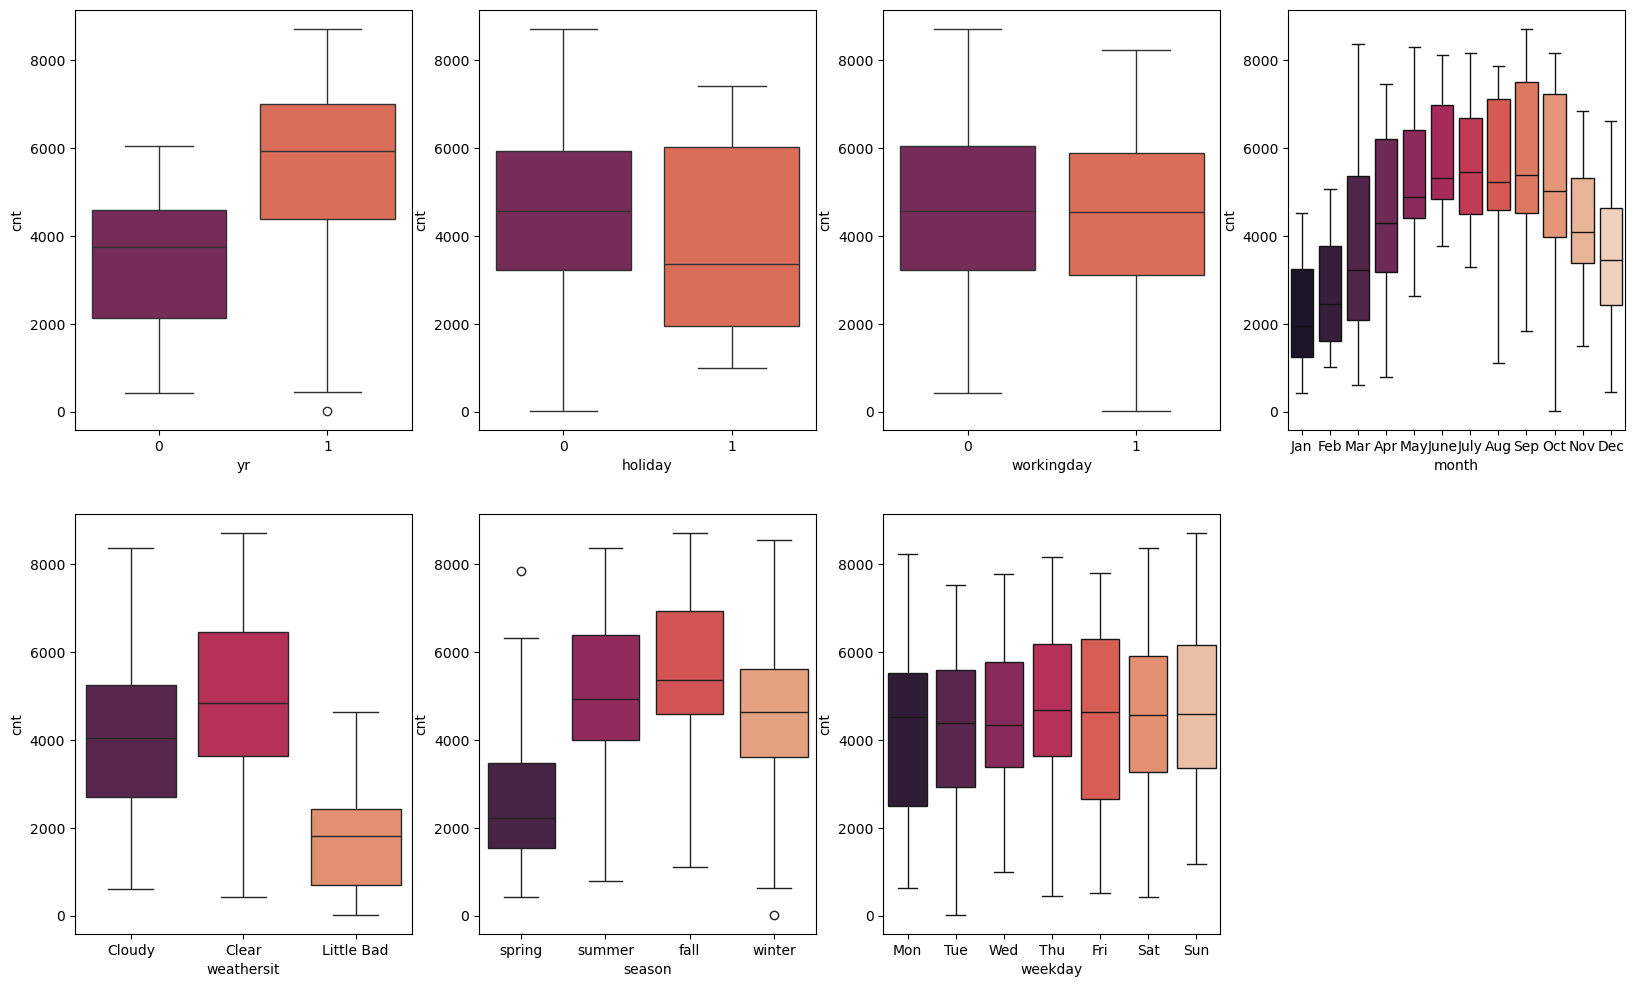

In [538]:
##Relationship between categorical and continuous variable
plt.figure(figsize=(20, 12))
plt.subplot(2,4,1)
sns.boxplot(x = 'yr', y = 'cnt', data = df_bike, palette="rocket")
plt.subplot(2,4,2)
sns.boxplot(x = 'holiday', y = 'cnt', data = df_bike, palette="rocket")
plt.subplot(2,4,3)
sns.boxplot(x = 'workingday', y = 'cnt', data = df_bike, palette="rocket")
plt.subplot(2,4,4)
sns.boxplot(x = 'month', y = 'cnt', data = df_bike, palette="rocket")
plt.subplot(2,4,5)
sns.boxplot(x = 'weathersit', y = 'cnt', data = df_bike, palette="rocket")
plt.subplot(2,4,6)
sns.boxplot(x = 'season', y = 'cnt', data = df_bike, palette="rocket")
plt.subplot(2,4,7)
sns.boxplot(x = 'weekday', y = 'cnt', data = df_bike, palette="rocket")

- Bike Rentals are more during the Fall season and then in summer
- Bike Rentals are more in the year 2019 compared to 2018
- Bike Rentals are more in Clear weather
- Bike Rentals are more on Thursday, Friday and Sunday

Text(0.5, 1.0, 'Monthly Average of All Monthly Txn (2018/ 2019)')

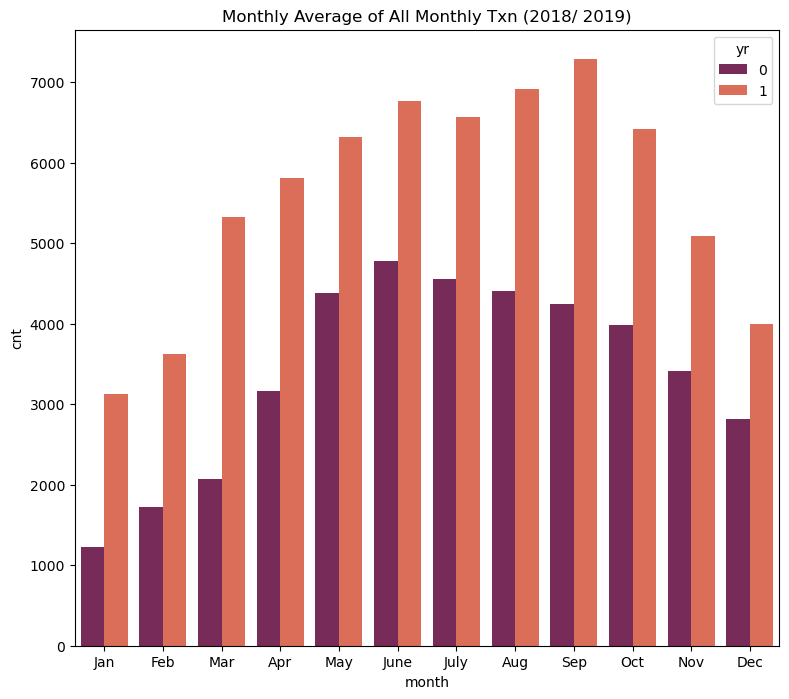

In [539]:
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(121)

sns.barplot(data=df_bike, x='month', y='cnt',hue='yr', errorbar=None, palette="rocket")
plt.title('Monthly Average of All Monthly Txn (2018/ 2019)')

Text(0, 0.5, 'Txn Count')

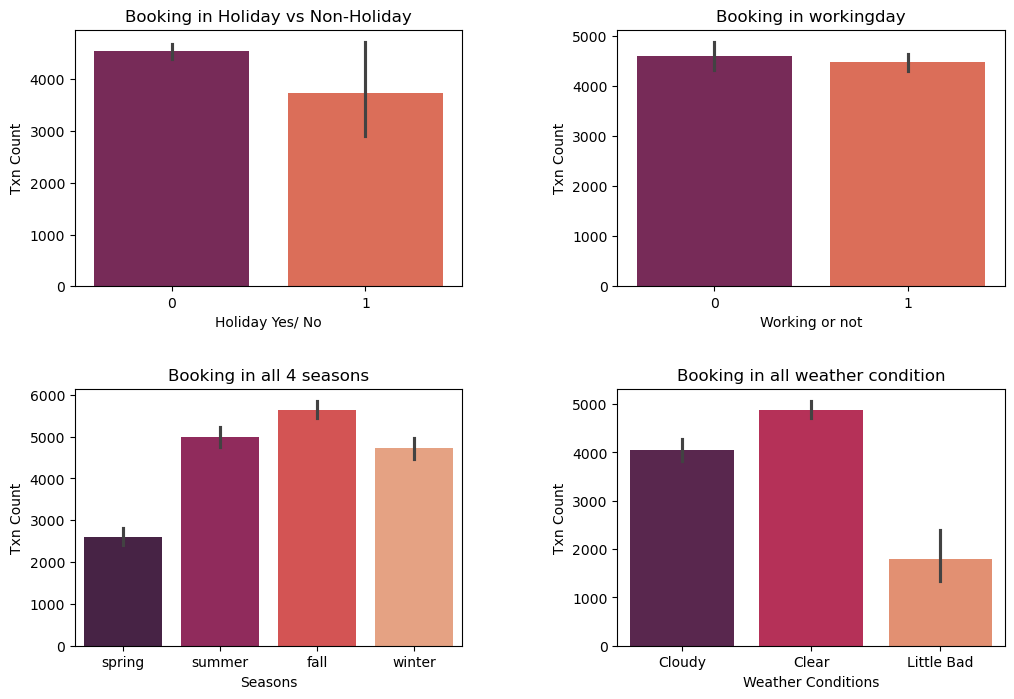

In [540]:
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

ax1 = fig.add_subplot(221)
sns.barplot(data=df_bike, x='holiday', y='cnt', palette="rocket")
plt.title('Booking in Holiday vs Non-Holiday')
plt.xlabel("Holiday Yes/ No")
plt.ylabel("Txn Count")

ax3 = fig.add_subplot(222)
sns.barplot(data=df_bike, x='workingday', y='cnt', palette="rocket")
plt.title('Booking in workingday')
plt.xlabel("Working or not")
plt.ylabel("Txn Count")

ax2 = fig.add_subplot(223)
sns.barplot(data=df_bike, x='season', y='cnt', palette="rocket")
plt.title('Booking in all 4 seasons')
plt.xlabel("Seasons")
plt.ylabel("Txn Count")

ax4 = fig.add_subplot(224)
sns.barplot(data=df_bike, x='weathersit', y='cnt', palette="rocket")
plt.title('Booking in all weather condition')
plt.xlabel("Weather Conditions")
plt.ylabel("Txn Count")


Text(0, 0.5, 'Cnt')

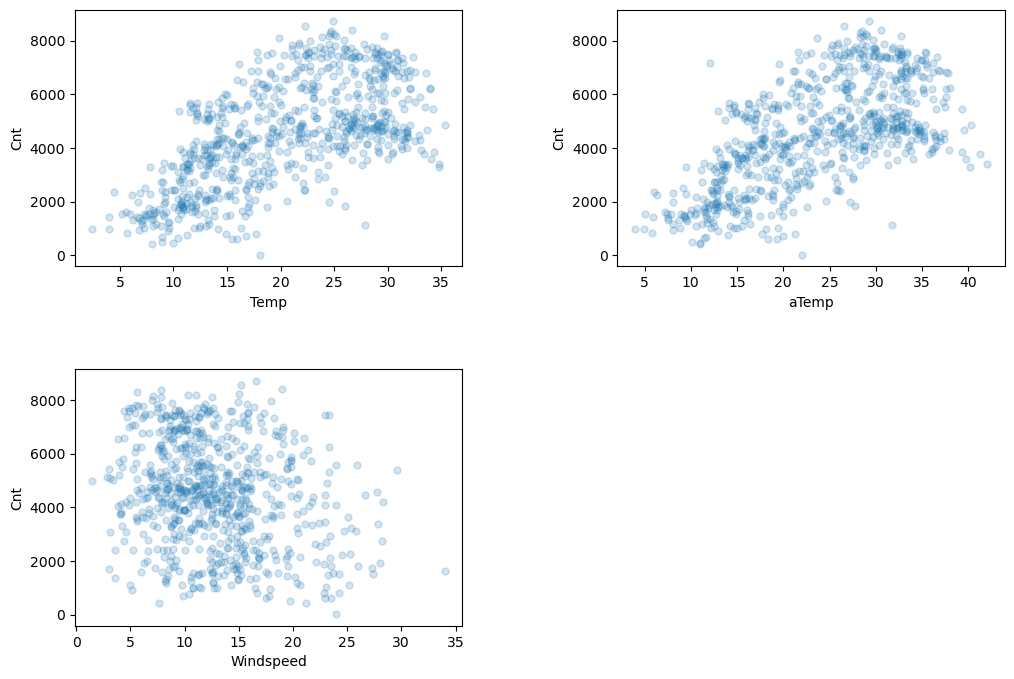

In [541]:
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

ax1 = fig.add_subplot(221)
plt.scatter(data=df_bike, x='temp', y='cnt', 
            alpha=0.2, s=25)
plt.xlabel("Temp")
plt.ylabel("Cnt")

ax1 = fig.add_subplot(222)
plt.scatter(data=df_bike, x='atemp', y='cnt', 
            alpha=0.2, s=25)
plt.xlabel("aTemp")
plt.ylabel("Cnt")

ax4 = fig.add_subplot(223)
plt.scatter(data=df_bike, x='windspeed', y='cnt', 
            alpha=0.2, s=25)
plt.xlabel("Windspeed")
plt.ylabel("Cnt")

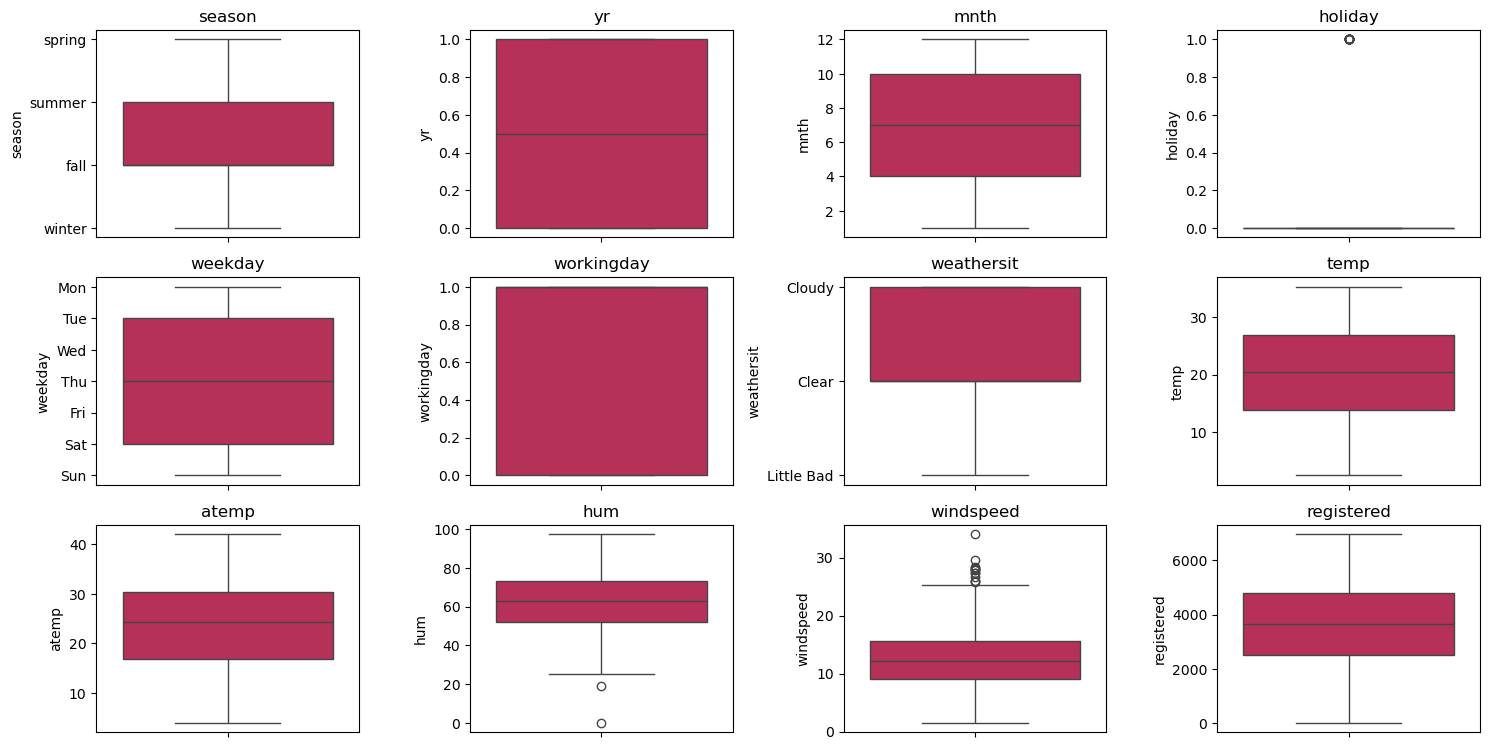

In [542]:
# Boxplots to visualize outliers in the dataset
plt.figure(figsize=(15, 10))

# Creating a boxplot for each feature in the DataFrame
for i, column in enumerate(df_bike[['season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'registered']]):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df_bike[column], palette="rocket")
    plt.title(column)
    plt.tight_layout()

In [543]:
#Print ouliers %
# for k, v in df_bike[['season', 'yr', 'mnth', 'holiday',
#        'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
#        'registered']].items():
#     q1 = v.quantile(0.25)
#     q3 = v.quantile(0.75)
#     irq = q3 - q1
#     v_col = v[(v <= q1 - 1.5 * irq) | (v >= q3 + 1.5 * irq)]
#     perc = np.shape(v_col)[0] * 100.0 / np.shape(df_bike)[0]
#     print("Column %s outliers = %.2f%%" % (k, perc))

TypeError: unsupported operand type(s) for -: 'str' and 'str'

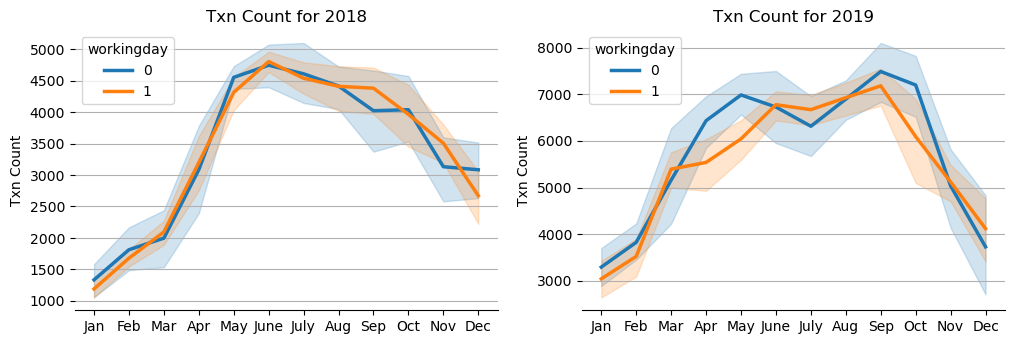

In [544]:
fig = plt.figure(figsize=(12, 8))
# fig.subplots_adjust(hspace=0.4, wspace=0.4)

ax1 = fig.add_subplot(221)
g = sns.lineplot(data=df_bike[df_bike['yr']==0], x='month', y='cnt', hue="workingday", linewidth = 2.5)
g.yaxis.grid(True)
g.set(xlabel="", ylabel="Txn Count", title="Txn Count for 2018")
sns.despine(left=True);

ax1 = fig.add_subplot(222)
g=sns.lineplot(data=df_bike[df_bike['yr']==1], x='month', y='cnt', hue="workingday", linewidth = 2.5)
g.yaxis.grid(True)
g.set(xlabel="", ylabel="Txn Count", title="Txn Count for 2019")
sns.despine(left=True);

<Figure size 640x480 with 0 Axes>

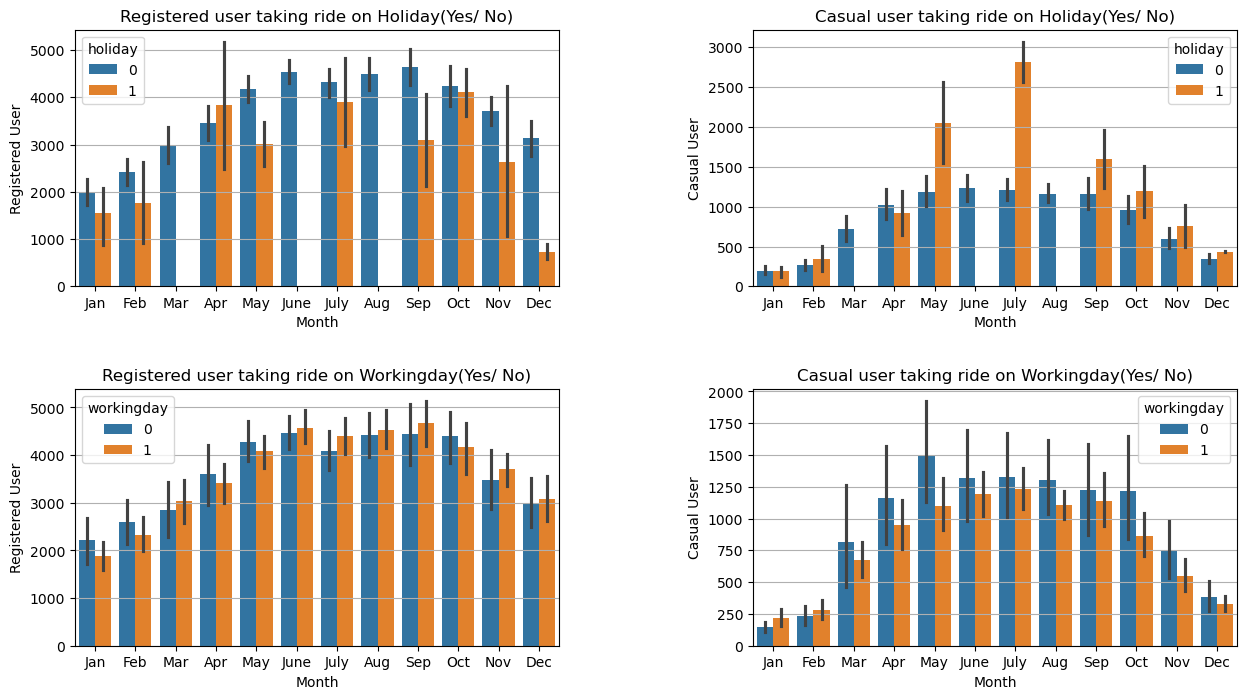

In [545]:
sns.despine(trim=True, left=True);

fig = plt.figure(figsize=(15, 8));
fig.subplots_adjust(hspace=0.4, wspace=0.4)

ax1 = fig.add_subplot(221);
g = sns.barplot(data=df_bike, x='month', y='registered', hue='holiday');
g.yaxis.grid(True);
g.set(xlabel="Month", ylabel="Registered User", title="Registered user taking ride on Holiday(Yes/ No)");

ax1 = fig.add_subplot(222);
g = sns.barplot(data=df_bike, x='month', y='casual', hue='holiday');
g.yaxis.grid(True);
g.set(xlabel="Month", ylabel="Casual User", title="Casual user taking ride on Holiday(Yes/ No)");

ax3 = fig.add_subplot(223);
g = sns.barplot(data=df_bike, x='month', y='registered', hue='workingday');
g.yaxis.grid(True);
g.set(xlabel="Month", ylabel="Registered User", title="Registered user taking ride on Workingday(Yes/ No)");

ax4 = fig.add_subplot(224);
g = sns.barplot(data=df_bike, x='month', y='casual', hue='workingday');
g.yaxis.grid(True);
g.set(xlabel="Month", ylabel="Casual User", title="Casual user taking ride on Workingday(Yes/ No)");

<Figure size 640x480 with 0 Axes>

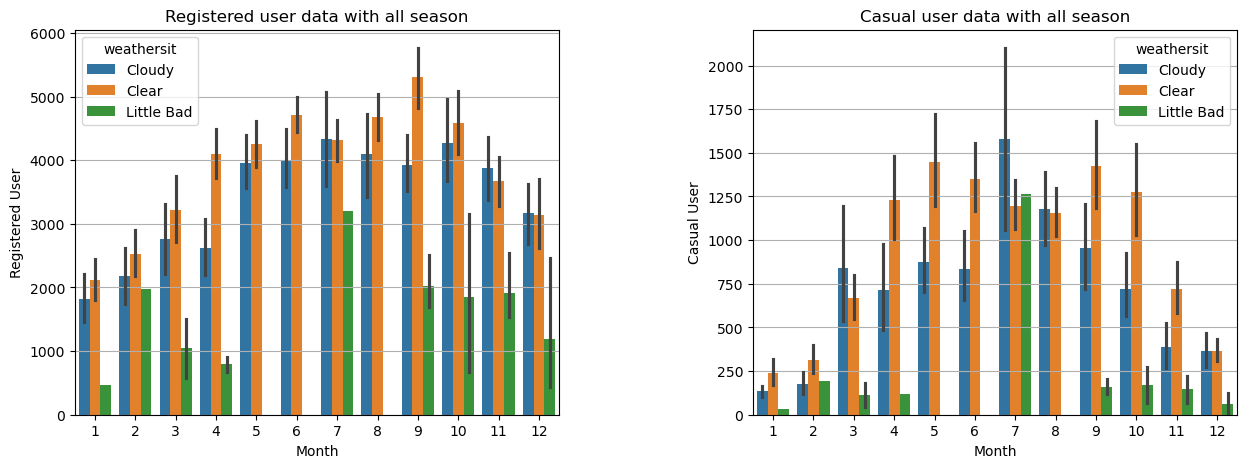

In [546]:
sns.despine(trim=True, left=True);

fig = plt.figure(figsize=(15, 12));
fig.subplots_adjust(hspace=0.4, wspace=0.4)

ax1 = fig.add_subplot(221);
g = sns.barplot(data=df_bike, x='mnth', y='registered', hue='weathersit');
g.yaxis.grid(True);
g.set(xlabel="Month", ylabel="Registered User", title="Registered user data with all season");

ax1 = fig.add_subplot(222);
g = sns.barplot(data=df_bike, x='mnth', y='casual', hue='weathersit');
g.yaxis.grid(True);
g.set(xlabel="Month", ylabel="Casual User", title="Casual user data with all season");

In [547]:
df_bike.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'month'],
      dtype='object')

In [551]:
print(correlation_matrix['cnt'].sort_values(ascending=False))

cnt           1.000000
temp          0.627044
yr            0.569728
June          0.195568
Sep           0.194664
Aug           0.182100
July          0.166236
summer        0.145325
May           0.132553
Oct           0.108846
winter        0.064619
Thu           0.038672
Sun           0.033227
Sat           0.025004
Wed          -0.013282
workingday   -0.027640
Nov          -0.040344
Tue          -0.049471
Mon          -0.052581
holiday      -0.068764
hum          -0.098543
Mar          -0.128456
Cloudy       -0.170686
Dec          -0.173878
windspeed    -0.235132
Little Bad   -0.240602
Feb          -0.273848
Jan          -0.367167
spring       -0.561702
Name: cnt, dtype: float64


In [ ]:
df_bike.info()

In [552]:
correlation_matrix = df_bike[numerical_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")

ValueError: could not convert string to float: 'spring'

In [553]:
#drop unnecessary columns
df_bike=df_bike.drop(['instant','dteday','casual', 'registered','atemp'], axis=1)
df_bike.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt,month
0,spring,0,1,0,Mon,1,Cloudy,14.110847,80.5833,10.749882,985,Jan
1,spring,0,1,0,Tue,1,Cloudy,14.902598,69.6087,16.652113,801,Jan
2,spring,0,1,0,Wed,1,Clear,8.050924,43.7273,16.636703,1349,Jan
3,spring,0,1,0,Thu,1,Clear,8.200000,59.0435,10.739832,1562,Jan
4,spring,0,1,0,Fri,1,Clear,9.305237,43.6957,12.522300,1600,Jan


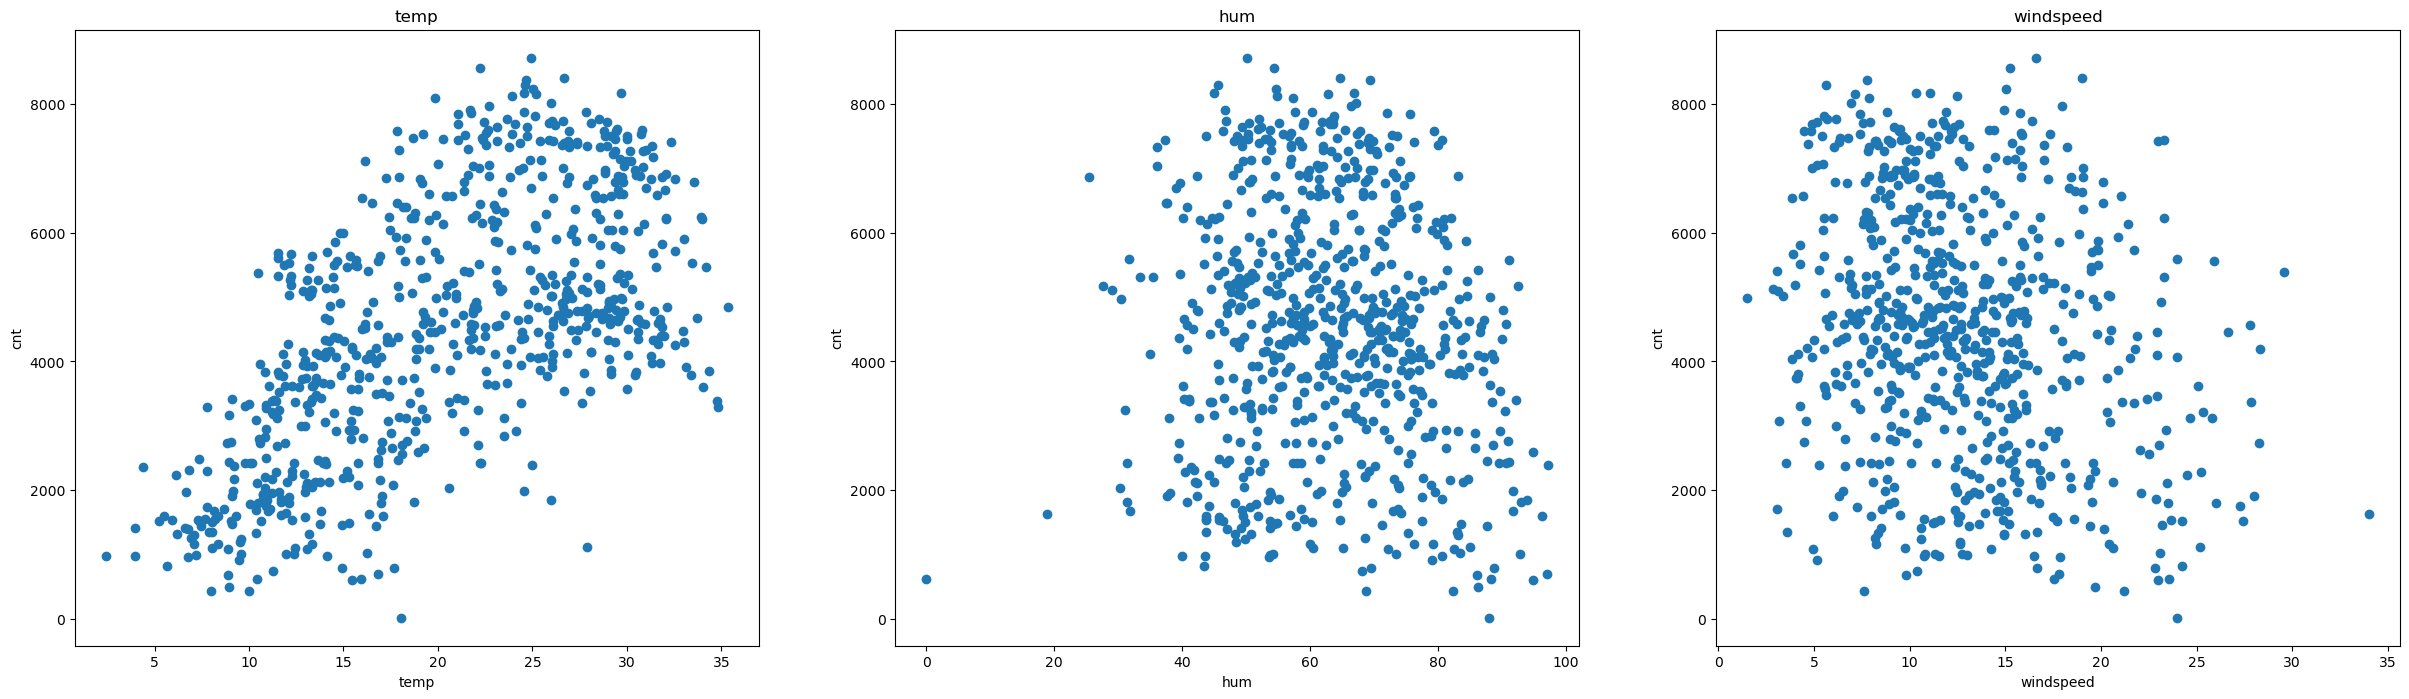

In [554]:
plt.figure(figsize=(30, 8))

features = ['temp', 'hum', 'windspeed']
target = df_bike['cnt']

for i, col in enumerate(features):
    plt.subplot(1, len(features) , i+1)
    x = df_bike[col]
    y = target
    plt.scatter(x, y, marker='o')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('cnt')

In [555]:
# # Get the dummy variables for month, season, weathersit, weekday and Let's drop the first column from  using 'drop_first = True'pd.get_dummies(bike.season,drop_first=True)
months=pd.get_dummies(df_bike.month,drop_first=True, dtype=int)
weekdays=pd.get_dummies(df_bike.weekday,drop_first=True, dtype=int)
weather_sit=pd.get_dummies(df_bike.weathersit,drop_first=True, dtype=int)
seasons=pd.get_dummies(df_bike.season,drop_first=True, dtype=int)

In [556]:
df_bike=pd.concat([months,weekdays,weather_sit,seasons,df_bike],axis=1)
df_bike.head()

,Aug,Dec,Feb,Jan,July,June,Mar,May,Nov,Oct,...,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt,month
0,0,0,0,1,0,0,0,0,0,0,...,1,0,Mon,1,Cloudy,14.110847,80.5833,10.749882,985,Jan
1,0,0,0,1,0,0,0,0,0,0,...,1,0,Tue,1,Cloudy,14.902598,69.6087,16.652113,801,Jan
2,0,0,0,1,0,0,0,0,0,0,...,1,0,Wed,1,Clear,8.050924,43.7273,16.636703,1349,Jan
3,0,0,0,1,0,0,0,0,0,0,...,1,0,Thu,1,Clear,8.200000,59.0435,10.739832,1562,Jan
4,0,0,0,1,0,0,0,0,0,0,...,1,0,Fri,1,Clear,9.305237,43.6957,12.522300,1600,Jan


In [557]:
df_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Aug         730 non-null    int64  
 1   Dec         730 non-null    int64  
 2   Feb         730 non-null    int64  
 3   Jan         730 non-null    int64  
 4   July        730 non-null    int64  
 5   June        730 non-null    int64  
 6   Mar         730 non-null    int64  
 7   May         730 non-null    int64  
 8   Nov         730 non-null    int64  
 9   Oct         730 non-null    int64  
 10  Sep         730 non-null    int64  
 11  Mon         730 non-null    int64  
 12  Sat         730 non-null    int64  
 13  Sun         730 non-null    int64  
 14  Thu         730 non-null    int64  
 15  Tue         730 non-null    int64  
 16  Wed         730 non-null    int64  
 17  Cloudy      730 non-null    int64  
 18  Little Bad  730 non-null    int64  
 19  spring      730 non-null    i

In [558]:
df_bike.drop(['season','month','weekday','weathersit'], axis = 1, inplace = True)
df_bike.head()

,Aug,Dec,Feb,Jan,July,June,Mar,May,Nov,Oct,...,summer,winter,yr,mnth,holiday,workingday,temp,hum,windspeed,cnt
0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,1,14.110847,80.5833,10.749882,985
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,1,14.902598,69.6087,16.652113,801
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,1,8.050924,43.7273,16.636703,1349
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,1,8.200000,59.0435,10.739832,1562
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,1,9.305237,43.6957,12.522300,1600


In [559]:
df_bike.drop(['mnth'], axis = 1, inplace = True)

In [560]:
df_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 29 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Aug         730 non-null    int64  
 1   Dec         730 non-null    int64  
 2   Feb         730 non-null    int64  
 3   Jan         730 non-null    int64  
 4   July        730 non-null    int64  
 5   June        730 non-null    int64  
 6   Mar         730 non-null    int64  
 7   May         730 non-null    int64  
 8   Nov         730 non-null    int64  
 9   Oct         730 non-null    int64  
 10  Sep         730 non-null    int64  
 11  Mon         730 non-null    int64  
 12  Sat         730 non-null    int64  
 13  Sun         730 non-null    int64  
 14  Thu         730 non-null    int64  
 15  Tue         730 non-null    int64  
 16  Wed         730 non-null    int64  
 17  Cloudy      730 non-null    int64  
 18  Little Bad  730 non-null    int64  
 19  spring      730 non-null    i

In [561]:
df_bike.shape

(730, 29)

<Axes: >

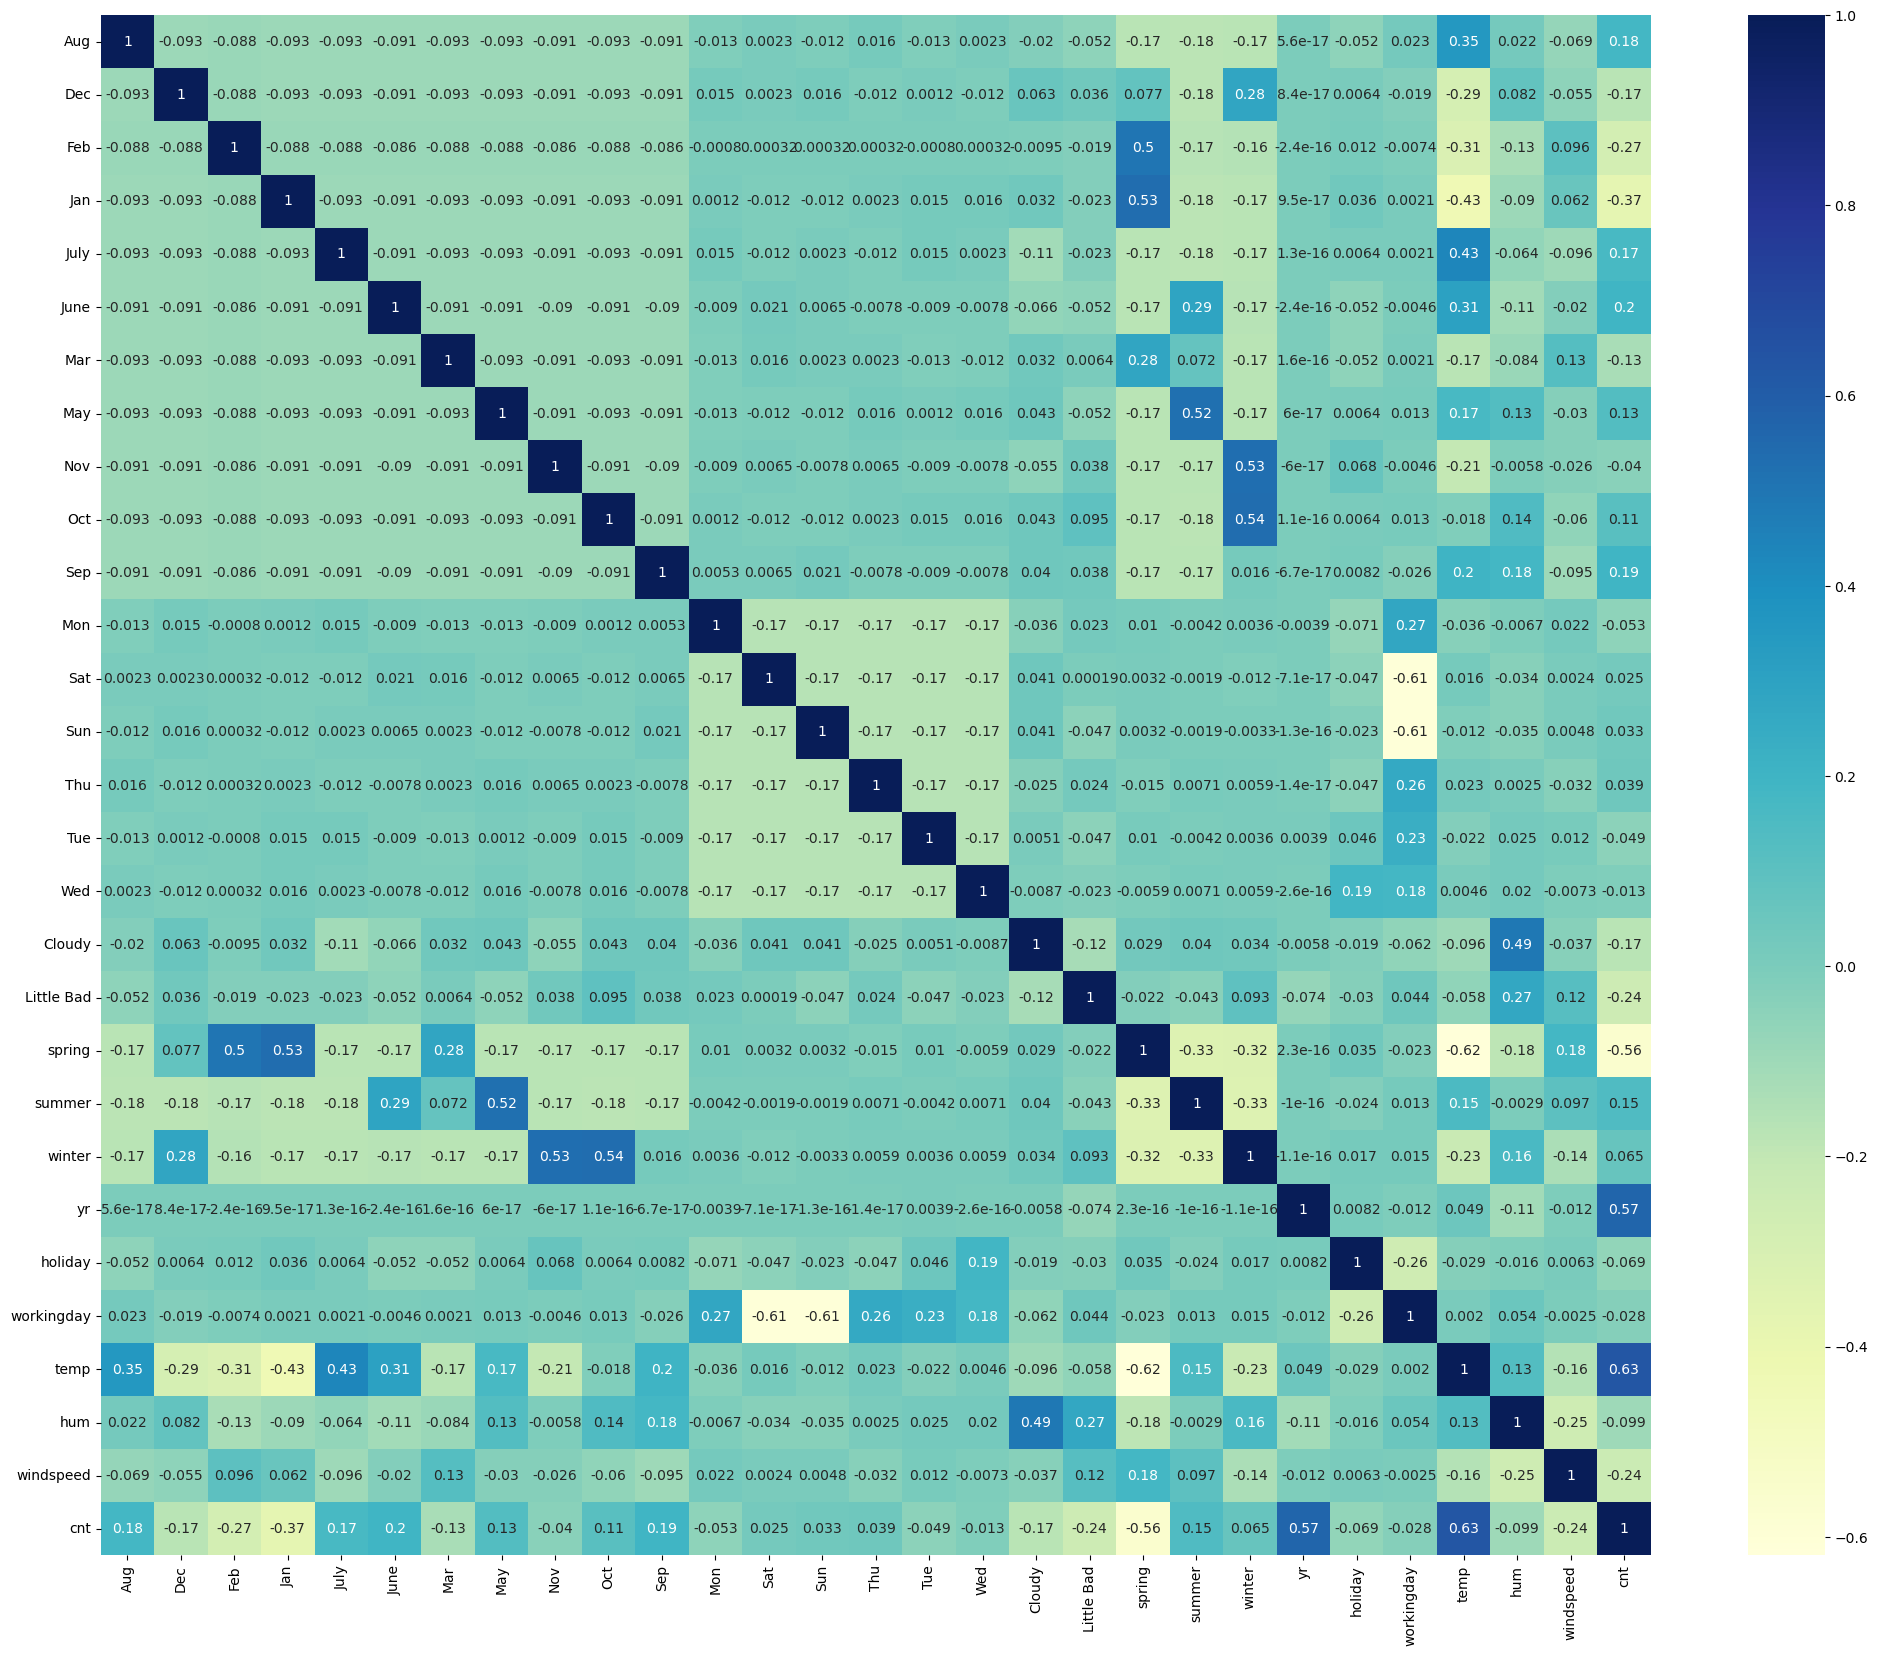

In [562]:
# check correlation once again 

plt.figure(figsize=(25, 20))
sns.heatmap(df_bike.corr(), cmap='YlGnBu', annot = True)

In [563]:
correlation_matrix = df_bike.select_dtypes(include=np.number).corr()
print(correlation_matrix['cnt'].sort_values(ascending=False))

cnt           1.000000
temp          0.627044
yr            0.569728
June          0.195568
Sep           0.194664
Aug           0.182100
July          0.166236
summer        0.145325
May           0.132553
Oct           0.108846
winter        0.064619
Thu           0.038672
Sun           0.033227
Sat           0.025004
Wed          -0.013282
workingday   -0.027640
Nov          -0.040344
Tue          -0.049471
Mon          -0.052581
holiday      -0.068764
hum          -0.098543
Mar          -0.128456
Cloudy       -0.170686
Dec          -0.173878
windspeed    -0.235132
Little Bad   -0.240602
Feb          -0.273848
Jan          -0.367167
spring       -0.561702
Name: cnt, dtype: float64


We can see that temperature,Summer season,May to october months are in good correlation with the 'count' variable.

In [564]:
train, test = train_test_split(df_bike, test_size=0.3, random_state=42)

In [565]:
#Rows and columns after split
print(train.shape)
print(test.shape)

(511, 29)
(219, 29)


In [566]:
# lets try to fit LR with above features
from sklearn.preprocessing import MinMaxScaler

num_vars = ['temp', 'hum', 'windspeed', 'cnt']

scaler = MinMaxScaler()

train[num_vars] = scaler.fit_transform(train[num_vars])
train.head()

,Aug,Dec,Feb,Jan,July,June,Mar,May,Nov,Oct,...,spring,summer,winter,yr,holiday,workingday,temp,hum,windspeed,cnt
683,0,0,0,0,0,0,0,0,1,0,...,0,0,1,1,0,1,0.327133,0.639330,0.327101,0.605336
645,0,0,0,0,0,0,0,0,0,1,...,0,0,1,1,1,0,0.403972,0.731215,0.419004,0.609320
163,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,1,0.717562,0.509660,0.708724,0.554026
360,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0.331287,0.785745,0.415925,0.088253
640,0,0,0,0,0,0,0,0,0,1,...,0,0,1,1,0,1,0.745598,0.817947,0.110593,0.862127


In [567]:
train.describe()

,Aug,Dec,Feb,Jan,July,June,Mar,May,Nov,Oct,...,spring,summer,winter,yr,holiday,workingday,temp,hum,windspeed,cnt
count,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.00000,...,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000
mean,0.074364,0.074364,0.074364,0.088063,0.091977,0.084149,0.062622,0.091977,0.091977,0.09002,...,0.230920,0.258317,0.250489,0.520548,0.027397,0.698630,0.550874,0.654174,0.414873,0.497640
std,0.262619,0.262619,0.262619,0.283664,0.289276,0.277883,0.242520,0.289276,0.289276,0.28649,...,0.421834,0.438138,0.433719,0.500067,0.163398,0.459303,0.227231,0.143648,0.185619,0.234026
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.354221,0.544598,0.281934,0.344984
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.575304,0.659940,0.384732,0.502113
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,1.000000,0.500000,1.000000,0.000000,1.000000,0.745079,0.756977,0.526481,0.676868
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

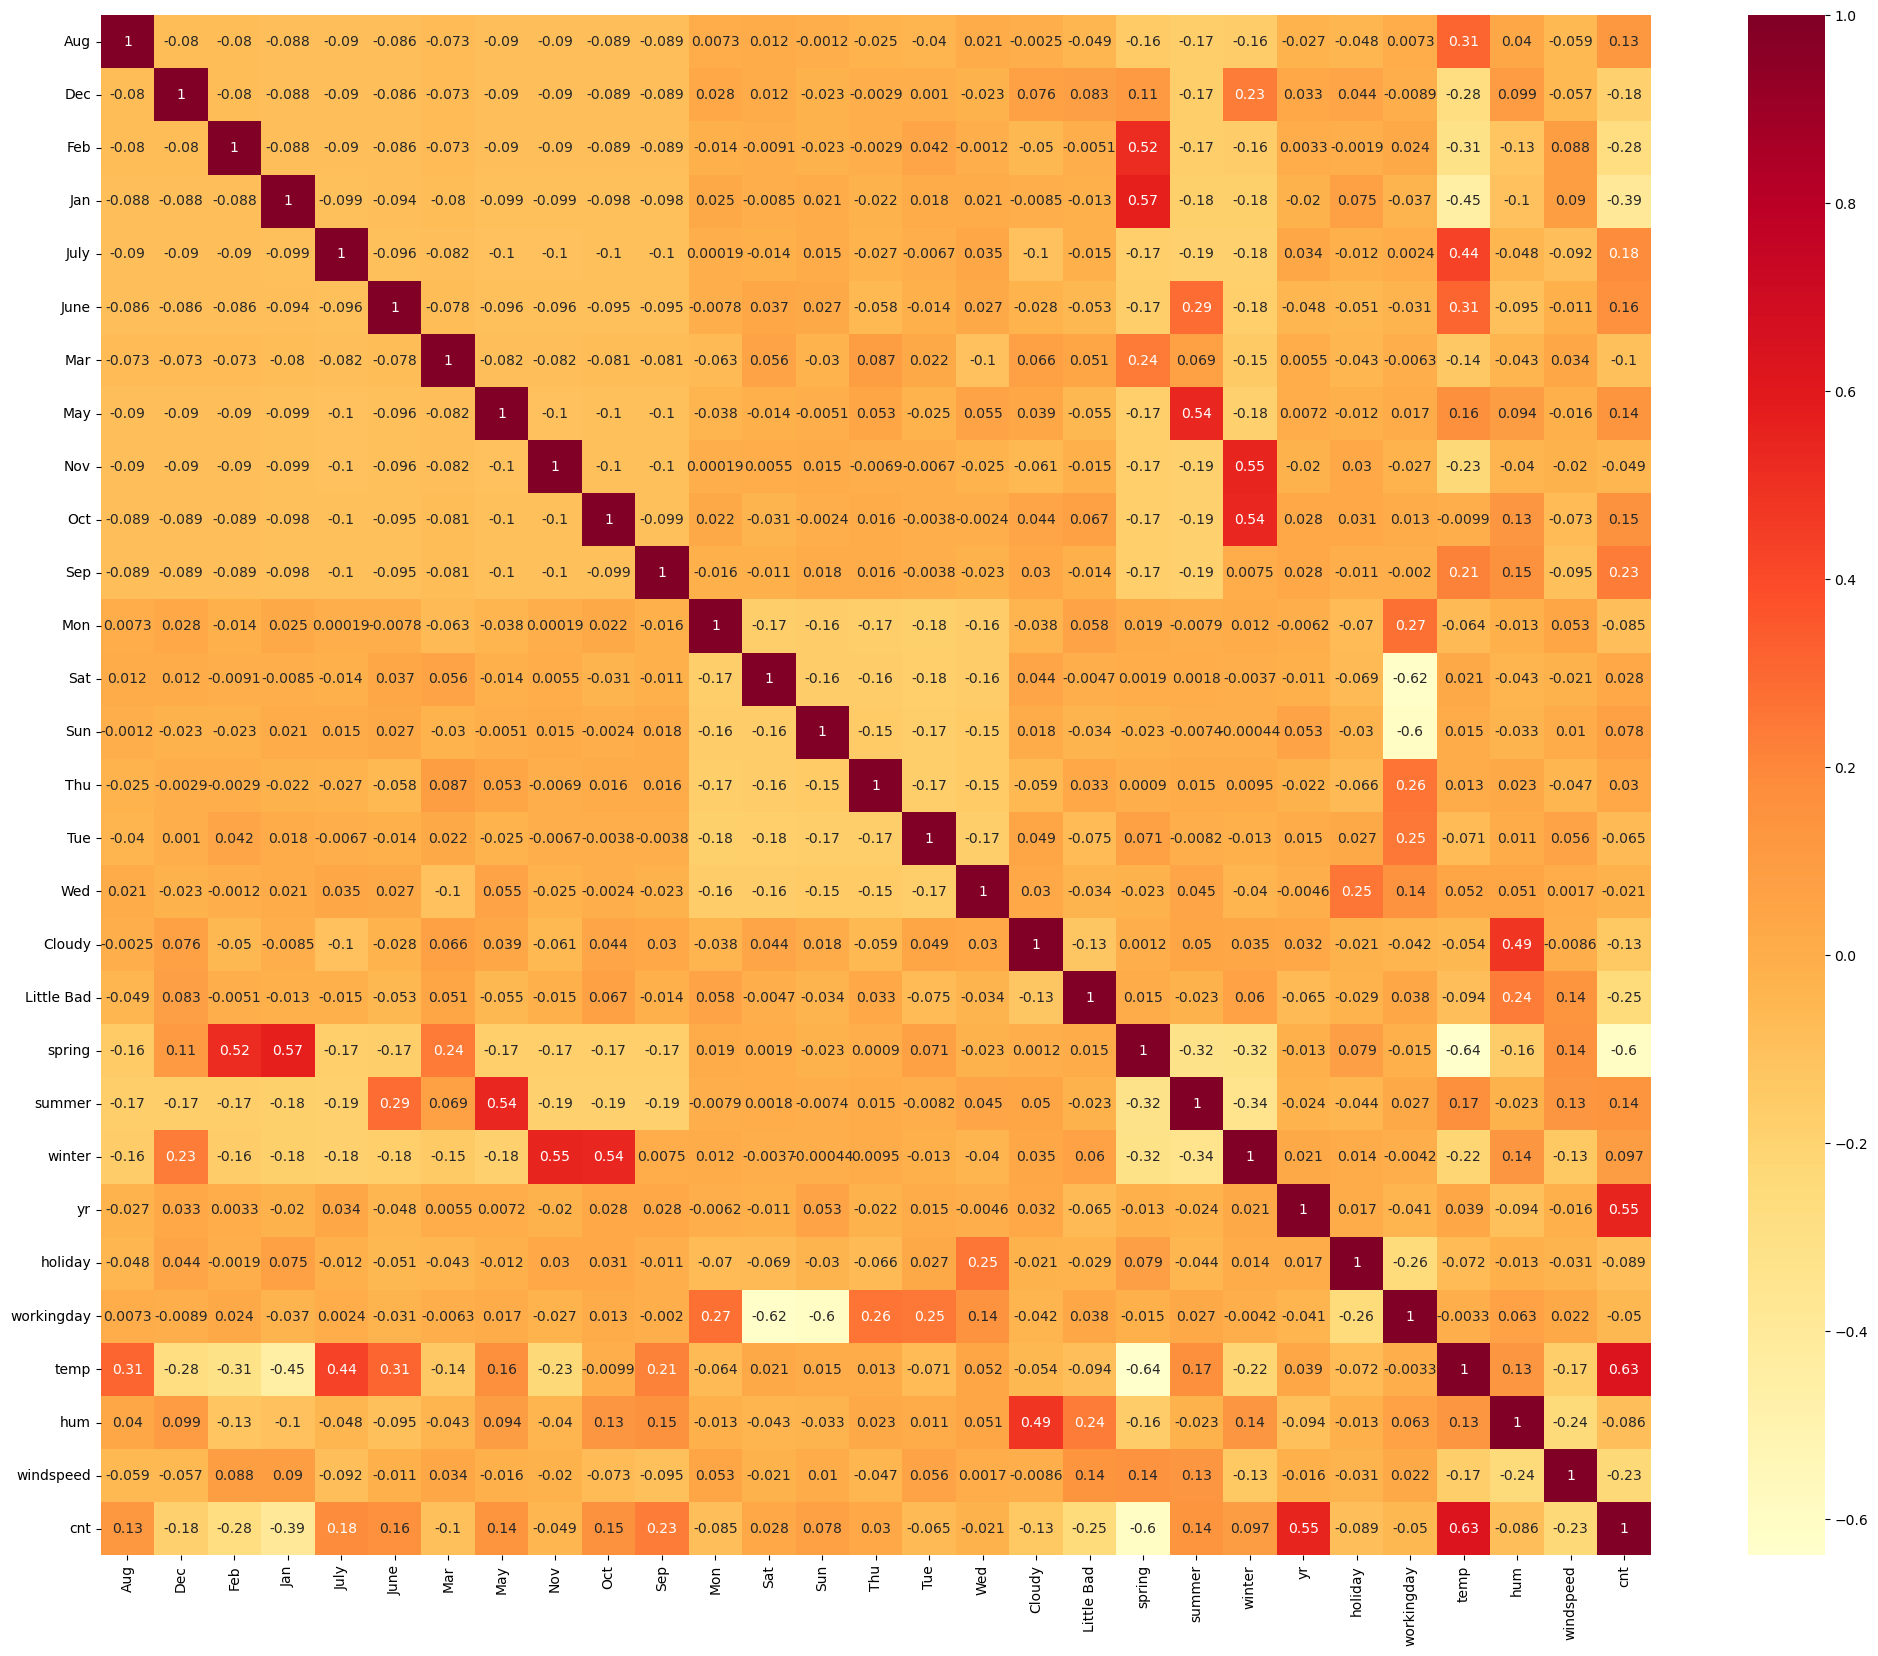

In [568]:
plt.figure(figsize=(25, 20))
sns.heatmap(train.corr(),cmap='YlOrRd',annot = True)

In [569]:
y_train = train.pop('cnt')
X_train = train

In [570]:
lr = LinearRegression()
lr.fit(X_train, y_train)

rfe = RFE(lr, n_features_to_select = 15)
rfe = rfe.fit(X_train, y_train)

In [571]:
#List of variables selected
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('Aug', np.False_, np.int64(8)),
 ('Dec', np.True_, np.int64(1)),
 ('Feb', np.False_, np.int64(7)),
 ('Jan', np.False_, np.int64(11)),
 ('July', np.True_, np.int64(1)),
 ('June', np.False_, np.int64(13)),
 ('Mar', np.True_, np.int64(1)),
 ('May', np.True_, np.int64(1)),
 ('Nov', np.True_, np.int64(1)),
 ('Oct', np.False_, np.int64(2)),
 ('Sep', np.True_, np.int64(1)),
 ('Mon', np.False_, np.int64(3)),
 ('Sat', np.False_, np.int64(10)),
 ('Sun', np.False_, np.int64(9)),
 ('Thu', np.False_, np.int64(14)),
 ('Tue', np.False_, np.int64(5)),
 ('Wed', np.False_, np.int64(4)),
 ('Cloudy', np.True_, np.int64(1)),
 ('Little Bad', np.True_, np.int64(1)),
 ('spring', np.True_, np.int64(1)),
 ('summer', np.False_, np.int64(6)),
 ('winter', np.True_, np.int64(1)),
 ('yr', np.True_, np.int64(1)),
 ('holiday', np.True_, np.int64(1)),
 ('workingday', np.False_, np.int64(12)),
 ('temp', np.True_, np.int64(1)),
 ('hum', np.True_, np.int64(1)),
 ('windspeed', np.True_, np.int64(1))]

In [572]:
#Columns where RFE support is True
col = X_train.columns[rfe.support_]
col

Index(['Dec', 'July', 'Mar', 'May', 'Nov', 'Sep', 'Cloudy', 'Little Bad',
       'spring', 'winter', 'yr', 'holiday', 'temp', 'hum', 'windspeed'],
      dtype='object')

In [573]:
# Creating X_test dataframe with RFE selected variables
X_train_rfe = X_train[col]

In [574]:
import statsmodels.api as sm  

X_train_rfe = sm.add_constant(X_train_rfe)

In [575]:
lm = sm.OLS(y_train,X_train_rfe).fit()

In [576]:
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     174.9
Date:                Sat, 10 Jan 2026   Prob (F-statistic):          9.97e-187
Time:                        21:50:33   Log-Likelihood:                 487.84
No. Observations:                 511   AIC:                            -943.7
Df Residuals:                     495   BIC:                            -875.9
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3399      0.036      9.354      0.0

In [577]:
X_train_rfe = X_train_rfe.drop(['const'], axis=1)

vif = pd.DataFrame()
X = X_train_rfe
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
13,hum,24.85
12,temp,16.95
14,windspeed,5.09
9,winter,2.91
8,spring,2.89
6,Cloudy,2.24
10,yr,2.10
4,Nov,1.84
1,July,1.57
0,Dec,1.38


In [578]:
#Drop humidity
X_train_new2 = X_train_rfe.drop(["hum"], axis = 1)

In [579]:
X_train_lm2 = sm.add_constant(X_train_new2)
lm2 = sm.OLS(y_train,X_train_lm2).fit()
print(lm2.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     179.9
Date:                Sat, 10 Jan 2026   Prob (F-statistic):          5.10e-184
Time:                        21:50:35   Log-Likelihood:                 478.65
No. Observations:                 511   AIC:                            -927.3
Df Residuals:                     496   BIC:                            -863.8
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2422      0.029      8.453      0.0

In [580]:
#Drop the constant term B0
X_train_lm2 = X_train_lm2.drop(['const'], axis=1)

In [581]:
vif = pd.DataFrame()
X = X_train_new2
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
12,temp,5.86
13,windspeed,5.05
9,winter,2.47
10,yr,2.09
8,spring,1.86
4,Nov,1.79
6,Cloudy,1.58
1,July,1.54
0,Dec,1.33
3,May,1.31


In [582]:
X_train_new3=X_train_lm2.drop(['Nov'],axis=1)

In [583]:
# Adding a constant variable 
X_train_lm3 = sm.add_constant(X_train_new3)
lm3 = sm.OLS(y_train,X_train_lm3).fit()
print(lm3.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     186.3
Date:                Sat, 10 Jan 2026   Prob (F-statistic):          1.71e-181
Time:                        21:50:37   Log-Likelihood:                 469.91
No. Observations:                 511   AIC:                            -911.8
Df Residuals:                     497   BIC:                            -852.5
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2136      0.028      7.556      0.0

In [584]:
#Drop constant 
X_train_lm3=X_train_lm3.drop(['const'],axis=1)

In [585]:
vif = pd.DataFrame()
X = X_train_new3
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
11,temp,5.79
12,windspeed,4.94
9,yr,2.09
7,spring,1.86
8,winter,1.61
5,Cloudy,1.57
1,July,1.54
3,May,1.31
4,Sep,1.28
0,Dec,1.23


In [586]:
#Drop July
X_train_new4= X_train_lm3.drop(['May'], axis=1)

In [587]:
#Build a model
X_train_lm4=sm.add_constant(X_train_new4)
lm4=sm.OLS(y_train,X_train_lm4).fit()
print(lm4.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     200.5
Date:                Sat, 10 Jan 2026   Prob (F-statistic):          6.85e-182
Time:                        21:50:40   Log-Likelihood:                 468.09
No. Observations:                 511   AIC:                            -910.2
Df Residuals:                     498   BIC:                            -855.1
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2223      0.028      7.950      0.0

In [588]:
vif = pd.DataFrame()
X = X_train_new4
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
10,temp,5.37
11,windspeed,4.93
8,yr,2.09
6,spring,1.82
4,Cloudy,1.57
7,winter,1.52
1,July,1.44
0,Dec,1.23
3,Sep,1.22
2,Mar,1.17


In [589]:
#Drop Dec
X_train_new5=X_train_lm4.drop(['Dec'], axis=1)

In [590]:
#Build a model
X_train_lm5=sm.add_constant(X_train_new5)
lm5=sm.OLS(y_train,X_train_lm5).fit()
print(lm5.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     216.3
Date:                Sat, 10 Jan 2026   Prob (F-statistic):          7.26e-182
Time:                        21:50:46   Log-Likelihood:                 465.24
No. Observations:                 511   AIC:                            -906.5
Df Residuals:                     499   BIC:                            -855.6
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2131      0.028      7.662      0.0

In [591]:
#Drop the constant
X_train_lm5=X_train_lm5.drop(['const'],axis=1)

In [592]:
vif = pd.DataFrame()
X = X_train_new5
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
0,const,40.74
10,temp,3.13
6,spring,2.79
7,winter,1.76
1,July,1.34
3,Sep,1.11
11,windspeed,1.10
2,Mar,1.09
5,Little Bad,1.06
4,Cloudy,1.04


In [606]:
#Drop temp for the lm4 model 
X_train_new6=X_train_lm5.drop(['holiday'], axis=1)

In [607]:
#Building a model
X_train_lm6= sm.add_constant(X_train_new6)
lm6=sm.OLS(y_train,X_train_lm6).fit()
print(lm6.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     233.5
Date:                Sat, 10 Jan 2026   Prob (F-statistic):          3.28e-181
Time:                        21:58:05   Log-Likelihood:                 460.86
No. Observations:                 511   AIC:                            -899.7
Df Residuals:                     500   BIC:                            -853.1
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2091      0.028      7.471      0.0

In [595]:
vif = pd.DataFrame()
X = X_train_new6
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
0,const,41.45
10,temp,3.19
7,spring,2.78
8,winter,1.79
2,July,1.34
1,Dec,1.16
4,Sep,1.11
3,Mar,1.10
11,windspeed,1.10
6,Little Bad,1.07


In [598]:
#y train predicted
y_train_pred = lm6.predict(X_train_lm6)

<Figure size 640x480 with 0 Axes>

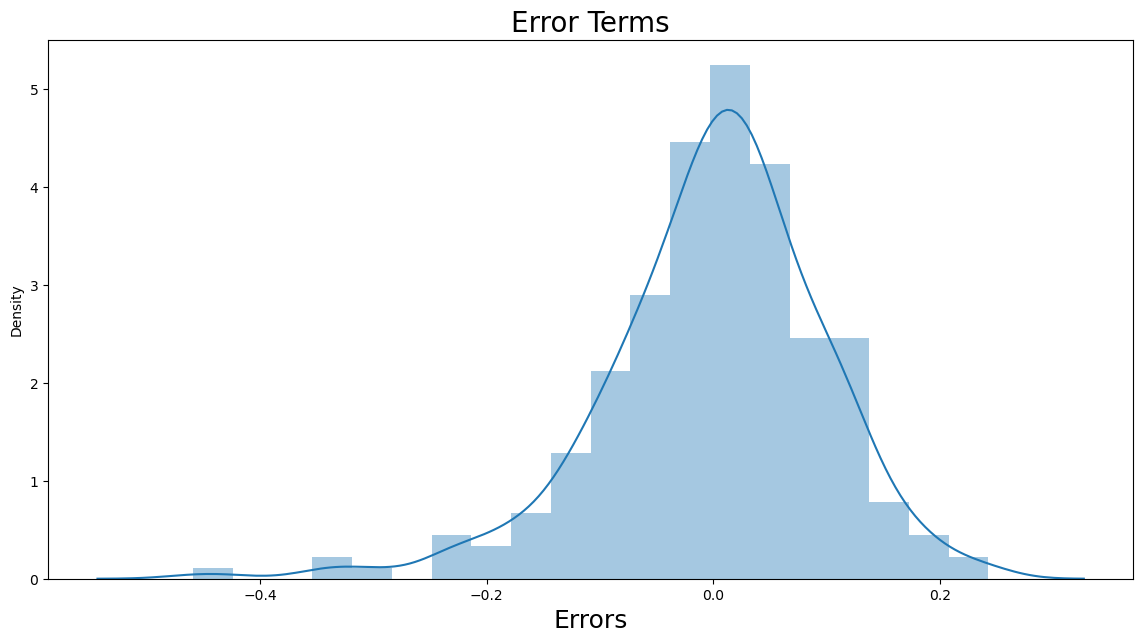

In [599]:
fig = plt.figure()
plt.figure(figsize=(14,7))
sns.distplot((y_train - y_train_pred), bins = 20)
plt.title('Error Terms', fontsize = 20)                  # Plot heading 
plt.xlabel('Errors', fontsize = 18)  # X-label
plt.show()

In [601]:
#Create a list of numeric variables
num_vars=['temp','hum','windspeed','cnt']

#Fit on data
test[num_vars] = scaler.transform(test[num_vars])
test.head()

,Aug,Dec,Feb,Jan,July,June,Mar,May,Nov,Oct,...,spring,summer,winter,yr,holiday,workingday,temp,hum,windspeed,cnt
468,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0.543115,0.518248,0.422104,0.848606
148,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,1,0.758058,0.843709,0.479765,0.526017
302,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,1,0.324018,0.642765,0.386287,0.350115
355,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0.453814,0.780592,0.062325,0.318363
515,0,0,0,0,0,0,0,1,0,0,...,0,1,0,1,0,1,0.773634,0.507943,0.433030,0.833877


In [603]:
#Dividing into X_test and y_test
y_test = test.pop('cnt')
X_test = test
X_test.describe()

,Aug,Dec,Feb,Jan,July,June,Mar,May,Nov,Oct,...,Little Bad,spring,summer,winter,yr,holiday,workingday,temp,hum,windspeed
count,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,...,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000
mean,0.109589,0.109589,0.082192,0.077626,0.068493,0.077626,0.136986,0.068493,0.059361,0.073059,...,0.027397,0.283105,0.237443,0.228311,0.452055,0.031963,0.671233,0.527468,0.629546,0.435511
std,0.313092,0.313092,0.275286,0.268194,0.253169,0.268194,0.344621,0.253169,0.236840,0.260830,...,0.163612,0.451539,0.426491,0.420705,0.498836,0.176306,0.470841,0.229936,0.152584,0.212750
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.047675,0.193646,0.060760
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.324018,0.520479,0.281156
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.507811,0.608416,0.416900
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.726388,0.735901,0.534288
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.970925,1.002146,1.214955


In [609]:
X_test_new = X_test[X_train_new6.columns]

# Adding a constant variable 
X_test_new1 = sm.add_constant(X_test_new)
X_test_new1.head()

,const,July,Mar,Sep,Cloudy,Little Bad,spring,winter,yr,temp,windspeed
468,1.0,0,0,0,0,0,0,0,1,0.543115,0.422104
148,1.0,0,0,0,0,0,0,0,0,0.758058,0.479765
302,1.0,0,0,0,0,0,0,1,0,0.324018,0.386287
355,1.0,0,0,0,1,0,1,0,0,0.453814,0.062325
515,1.0,0,0,0,0,0,0,0,1,0.773634,0.433030


In [611]:
# Making predictions
y_pred = lm6.predict(X_test_new1)

In [612]:
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"R-Squared: {r2_score(y_test, y_pred)}")

MSE: 0.00969943940402979
R-Squared: 0.8206578215878981


Text(0, 0.5, 'y_pred')

<Figure size 640x480 with 0 Axes>

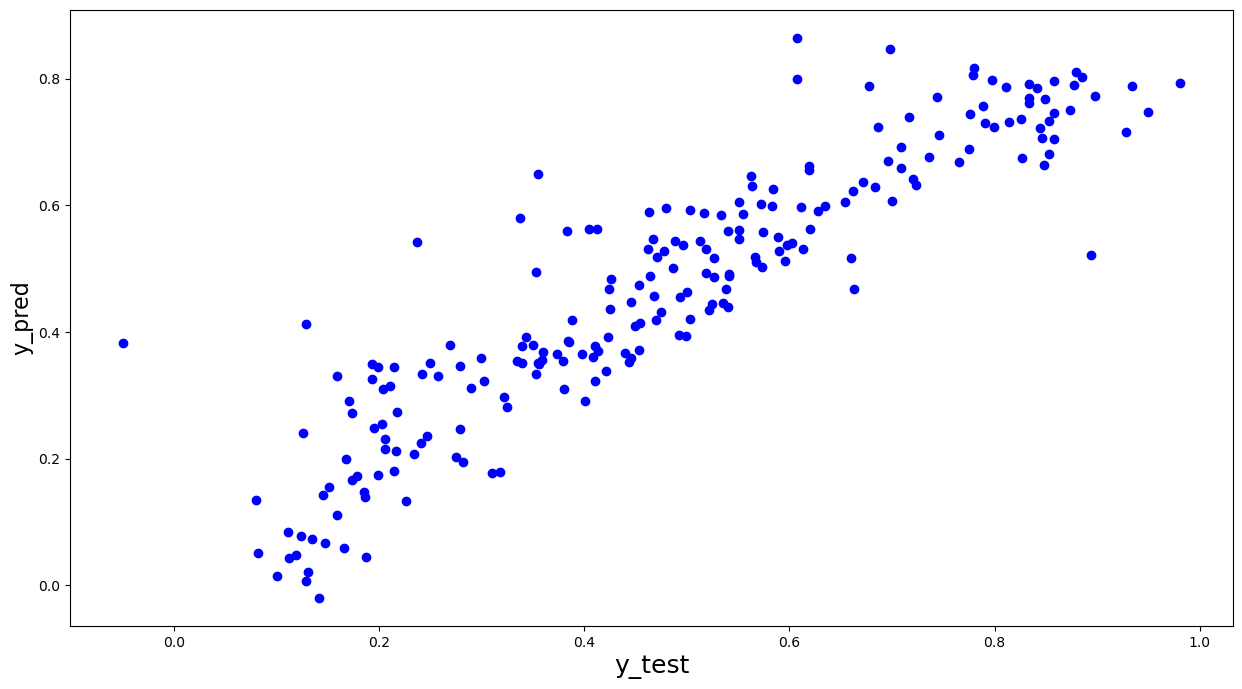

In [613]:
# Plotting y_test and y_pred to understand the spread.
fig = plt.figure()
plt.figure(figsize=(15,8))
plt.scatter(y_test,y_pred,color='blue')
fig.suptitle('y_test vs y_pred', fontsize=20)              # Plot heading 
plt.xlabel('y_test', fontsize=18)                          # X-label
plt.ylabel('y_pred', fontsize=16) 